# 06: 改进策略风险分析

对改进后的最优策略进行与 04 相同的风险分析框架：

1. **Vega 风险拆解**
2. **Delta 风险拆解**
3. **Gamma 风险拆解**
4. **组合 P&L 归因**
5. **收益分布与回撤结构**

改进策略参数（来自 05_improved.ipynb）：
- Call+Put 组合
- 滚动阈值 (5年 lookback, 20日窗口, 85分位)
- 停止交易 (min_t=7, hedge=False)

> 与 04 的基准策略进行对比分析。

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline

sns.set_style('whitegrid')
from src.utils.visualize import setup_chinese_font
setup_chinese_font()

from src.data.preprocess import prepare_etf_daily, prepare_options_daily_with_greeks
from src.models.vol_cone import build_vol_cone, compute_rolling_threshold, get_vol_threshold
from src.models.greeks import gamma as bsm_gamma, vega as bsm_vega, theta as bsm_theta
from src.strategy.backtest import VolArbBacktest

SAVE_DIR = '../Data/processed/'
print('Imports OK')

Matplotlib is building the font cache; this may take a moment.


Imports OK


## 0. 数据准备与改进策略回测

In [2]:
# 加载数据
etf = prepare_etf_daily(start_date='2010-01-01', end_date='2025-12-31')
opts_c = prepare_options_daily_with_greeks(start_date='2015-02-09', end_date='2025-12-31', option_type='C')
opts_p = prepare_options_daily_with_greeks(start_date='2015-02-09', end_date='2025-12-31', option_type='P')
print(f'ETF: {etf.shape[0]} 天')
print(f'Call: {opts_c["code"].nunique()} 合约, Put: {opts_p["code"].nunique()} 合约')

# 滚动阈值
rolling_threshold = compute_rolling_threshold(etf, lookback_years=5, window=20, percentile=85)
print(f'滚动阈值: {len(rolling_threshold)} 日')

ETF: 3885 天
Call: 3400 合约, Put: 3403 合约
滚动阈值: 2625 日


In [3]:
# 运行改进策略回测: Call + Put, 滚动阈值, 停止交易(min_t=7)
def run_improved_backtest(opts, etf, rolling_threshold, option_type='call'):
    all_trades = []
    all_daily_greeks = []
    all_daily_pnl = []
    expiries = sorted(opts['EXPIRY_DATE'].unique())
    for i, expiry in enumerate(expiries):
        bt = VolArbBacktest(r=0.04, commission_rate=0.0005,
                            min_t_days=7, close_t_days=5,
                            rolling_threshold=rolling_threshold,
                            hedge=False, option_type=option_type)
        result = bt.run(opts, etf, expiry_date=expiry, early_close=False)
        all_trades.extend(result.trades)
        if not result.daily_greeks.empty:
            all_daily_greeks.append(result.daily_greeks)
        if not result.equity_curve.empty:
            eq = result.equity_curve
            daily_delta = eq.diff().fillna(eq)
            all_daily_pnl.append(daily_delta)
        if (i+1) % 30 == 0:
            print(f'  Progress: {i+1}/{len(expiries)}')
    return all_trades, all_daily_greeks, all_daily_pnl

# Call
print('Running improved Call backtest...')
trades_c, greeks_c, pnl_c = run_improved_backtest(opts_c, etf, rolling_threshold, 'call')

# Put
print('Running improved Put backtest...')
trades_p, greeks_p, pnl_p = run_improved_backtest(opts_p, etf, rolling_threshold, 'put')

# 合并
all_trades = trades_c + trades_p

# 汇总 Greeks
all_greeks = greeks_c + greeks_p
if all_greeks:
    greeks_daily = pd.concat(all_greeks)
    greeks_daily = greeks_daily.groupby(greeks_daily.index).agg({
        'etf_price': 'last', 'num_positions': 'sum',
        'portfolio_delta': 'sum', 'portfolio_delta_option': 'sum',
        'portfolio_gamma': 'sum',
        'portfolio_vega': 'sum', 'portfolio_theta': 'sum',
    })
else:
    greeks_daily = pd.DataFrame()

# 汇总 P&L
all_pnl = pnl_c + pnl_p
if all_pnl:
    combined = pd.concat(all_pnl)
    equity = combined.groupby(combined.index).sum().cumsum()
else:
    equity = pd.Series(dtype=float)

total_pnl = sum(t.pnl for t in all_trades)
print(f'\n改进策略回测完成: {len(all_trades)} 笔交易, 总 PnL={total_pnl:,.0f} 元')
print(f'  Call: {len(trades_c)} 笔, Put: {len(trades_p)} 笔')
print(f'  Greeks 数据: {len(greeks_daily)} 天')

Running improved Call backtest...
  Progress: 30/134
  Progress: 60/134
  Progress: 90/134
  Progress: 120/134
Running improved Put backtest...
  Progress: 30/134
  Progress: 60/134
  Progress: 90/134
  Progress: 120/134

改进策略回测完成: 63535 笔交易, 总 PnL=15,046,317 元
  Call: 16214 笔, Put: 47321 笔
  Greeks 数据: 2476 天


In [4]:
# 计算 P&L 归因
daily_iv_c = opts_c.groupby('date')['iv'].mean()
daily_iv_p = opts_p.groupby('date')['iv'].mean()
daily_iv = pd.concat([daily_iv_c, daily_iv_p]).groupby(level=0).mean()

greeks_daily['market_iv'] = daily_iv.reindex(greeks_daily.index)
greeks_daily['dS'] = greeks_daily['etf_price'].diff()
greeks_daily['dIV'] = greeks_daily['market_iv'].diff()
greeks_daily['daily_pnl'] = equity.diff().fillna(0).reindex(greeks_daily.index, fill_value=0)

greeks_daily['vega_pnl'] = greeks_daily['portfolio_vega'] * greeks_daily['dIV'] * 100
greeks_daily['gamma_pnl'] = 0.5 * greeks_daily['portfolio_gamma'] * greeks_daily['dS']**2
greeks_daily['theta_pnl'] = greeks_daily['portfolio_theta']
greeks_daily['delta_pnl'] = greeks_daily['portfolio_delta_option'] * greeks_daily['dS']
greeks_daily['residual_pnl'] = greeks_daily['daily_pnl'] - (
    greeks_daily['vega_pnl'] + greeks_daily['gamma_pnl'] +
    greeks_daily['theta_pnl'] + greeks_daily['delta_pnl']
)

print('Greeks 归因计算完成')

Greeks 归因计算完成


## 1. Vega 风险拆解

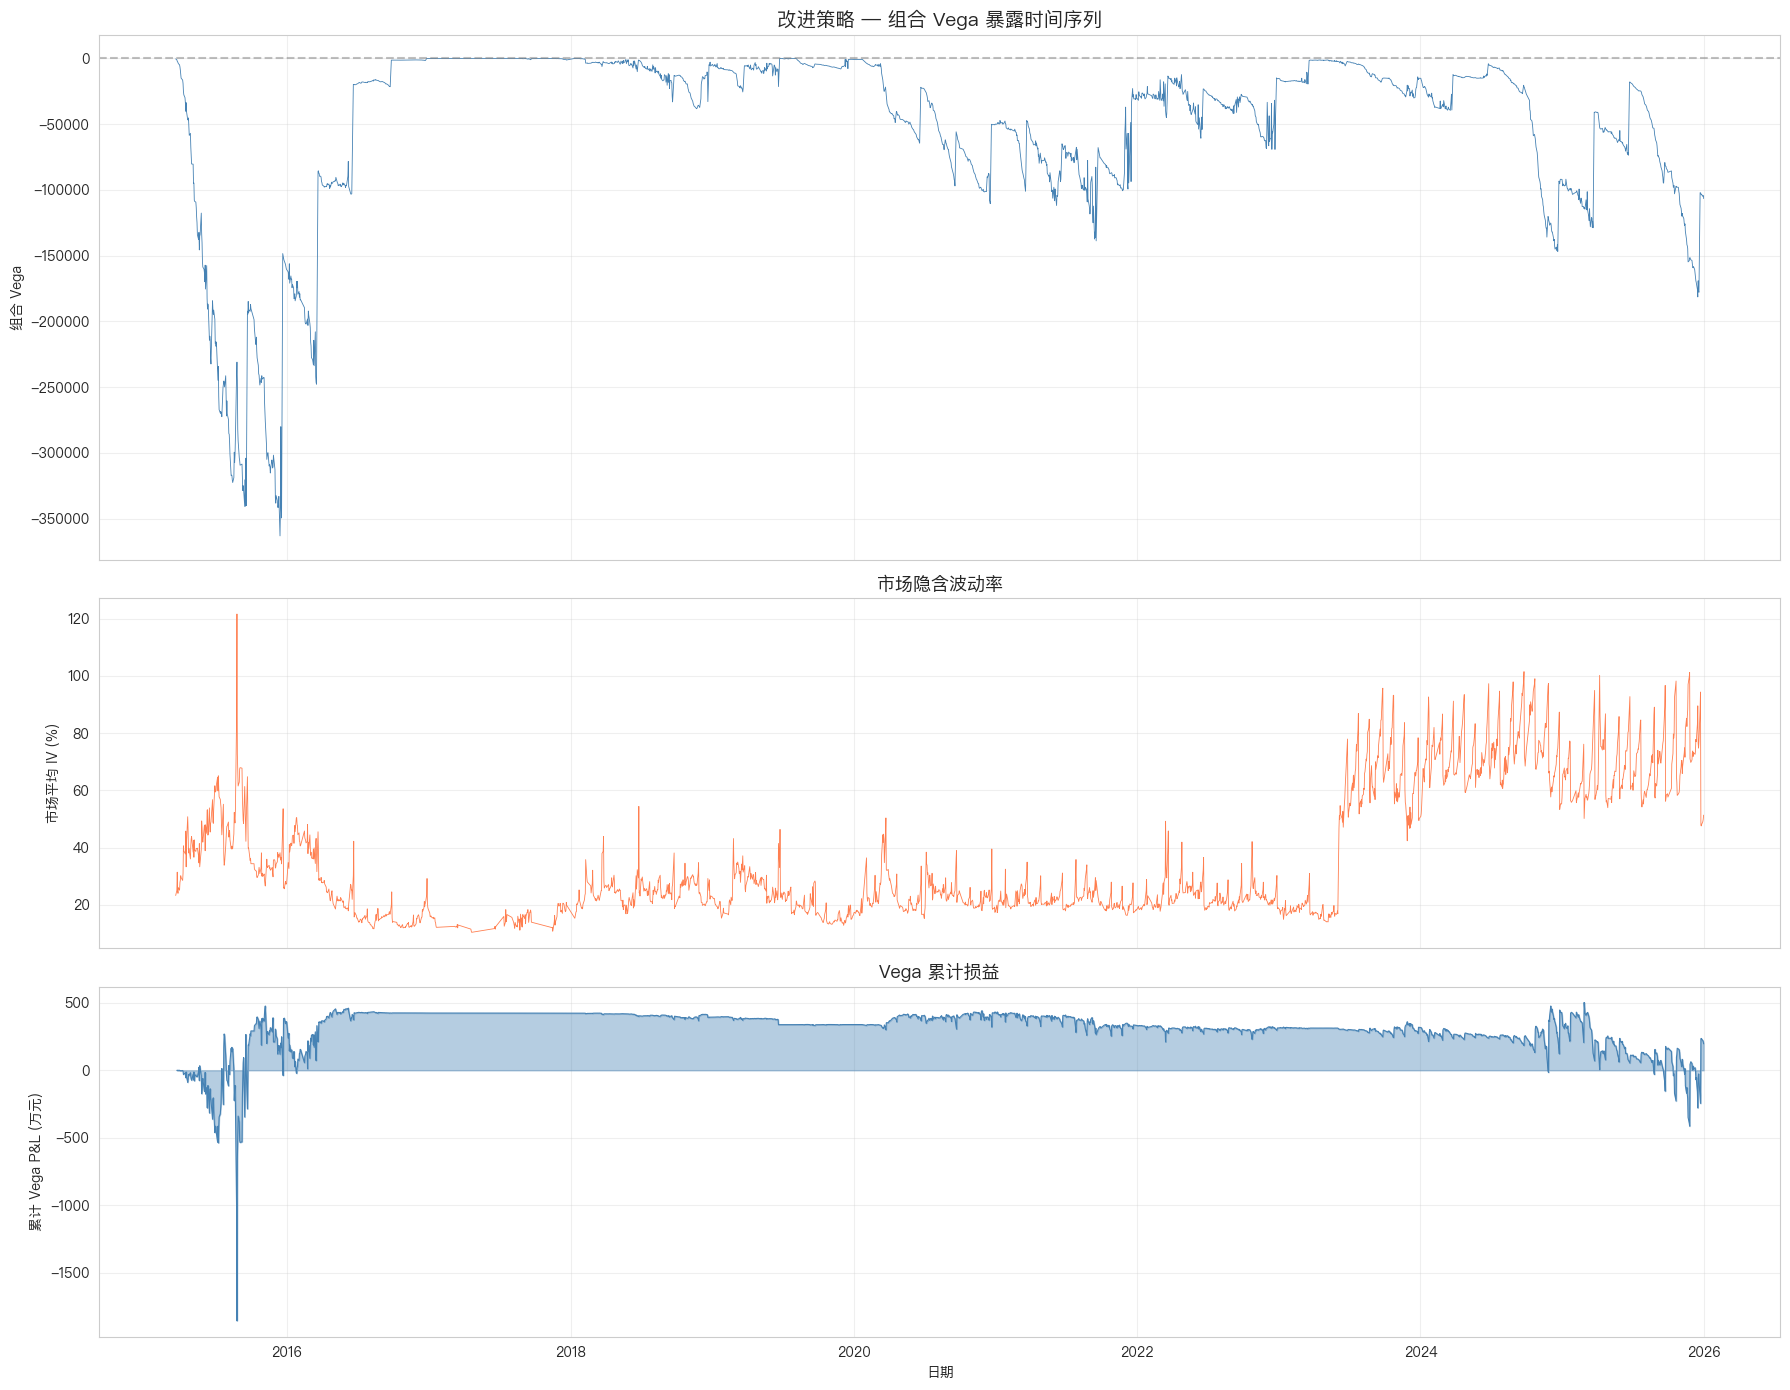

Vega 统计:
  平均 Vega: -53,785
  累计 Vega P&L: 1,961,771 元


In [5]:
# 1.1 组合 Vega 时间序列
fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True,
                         gridspec_kw={'height_ratios': [1.5, 1, 1]})

axes[0].plot(greeks_daily.index, greeks_daily['portfolio_vega'], linewidth=0.6, color='steelblue')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_ylabel('组合 Vega')
axes[0].set_title('改进策略 — 组合 Vega 暴露时间序列', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(greeks_daily.index, greeks_daily['market_iv'] * 100, linewidth=0.6, color='coral')
axes[1].set_ylabel('市场平均 IV (%)')
axes[1].set_title('市场隐含波动率', fontsize=13)
axes[1].grid(True, alpha=0.3)

axes[2].fill_between(greeks_daily.index, greeks_daily['vega_pnl'].cumsum() / 10000,
                     0, alpha=0.4, color='steelblue')
axes[2].plot(greeks_daily.index, greeks_daily['vega_pnl'].cumsum() / 10000,
             linewidth=0.8, color='steelblue')
axes[2].set_ylabel('累计 Vega P&L (万元)')
axes[2].set_xlabel('日期')
axes[2].set_title('Vega 累计损益', fontsize=13)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + '06_vega_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Vega 统计:')
print(f'  平均 Vega: {greeks_daily["portfolio_vega"].mean():,.0f}')
print(f'  累计 Vega P&L: {greeks_daily["vega_pnl"].sum():,.0f} 元')

In [6]:
# 1.2 Vega 压力测试
shocks = [0.03, 0.05, 0.10, 0.15]
print('=== Vega 压力测试 (改进策略) ===')
print(f'{"IV 冲击":>10s} {"单日 Vega PnL":>15s} {"占总 PnL 比":>12s}')
print('-' * 40)

avg_vega = greeks_daily['portfolio_vega'].mean()
for shock in shocks:
    pnl_shock = avg_vega * shock * 100
    pct = pnl_shock / total_pnl * 100 if total_pnl != 0 else 0
    print(f'{shock*100:>+9.0f}% {pnl_shock:>15,.0f} {pct:>11.1f}%')

=== Vega 压力测试 (改进策略) ===
     IV 冲击     单日 Vega PnL     占总 PnL 比
----------------------------------------
       +3%        -161,355        -1.1%
       +5%        -268,924        -1.8%
      +10%        -537,849        -3.6%
      +15%        -806,773        -5.4%


## 2. Delta 风险拆解

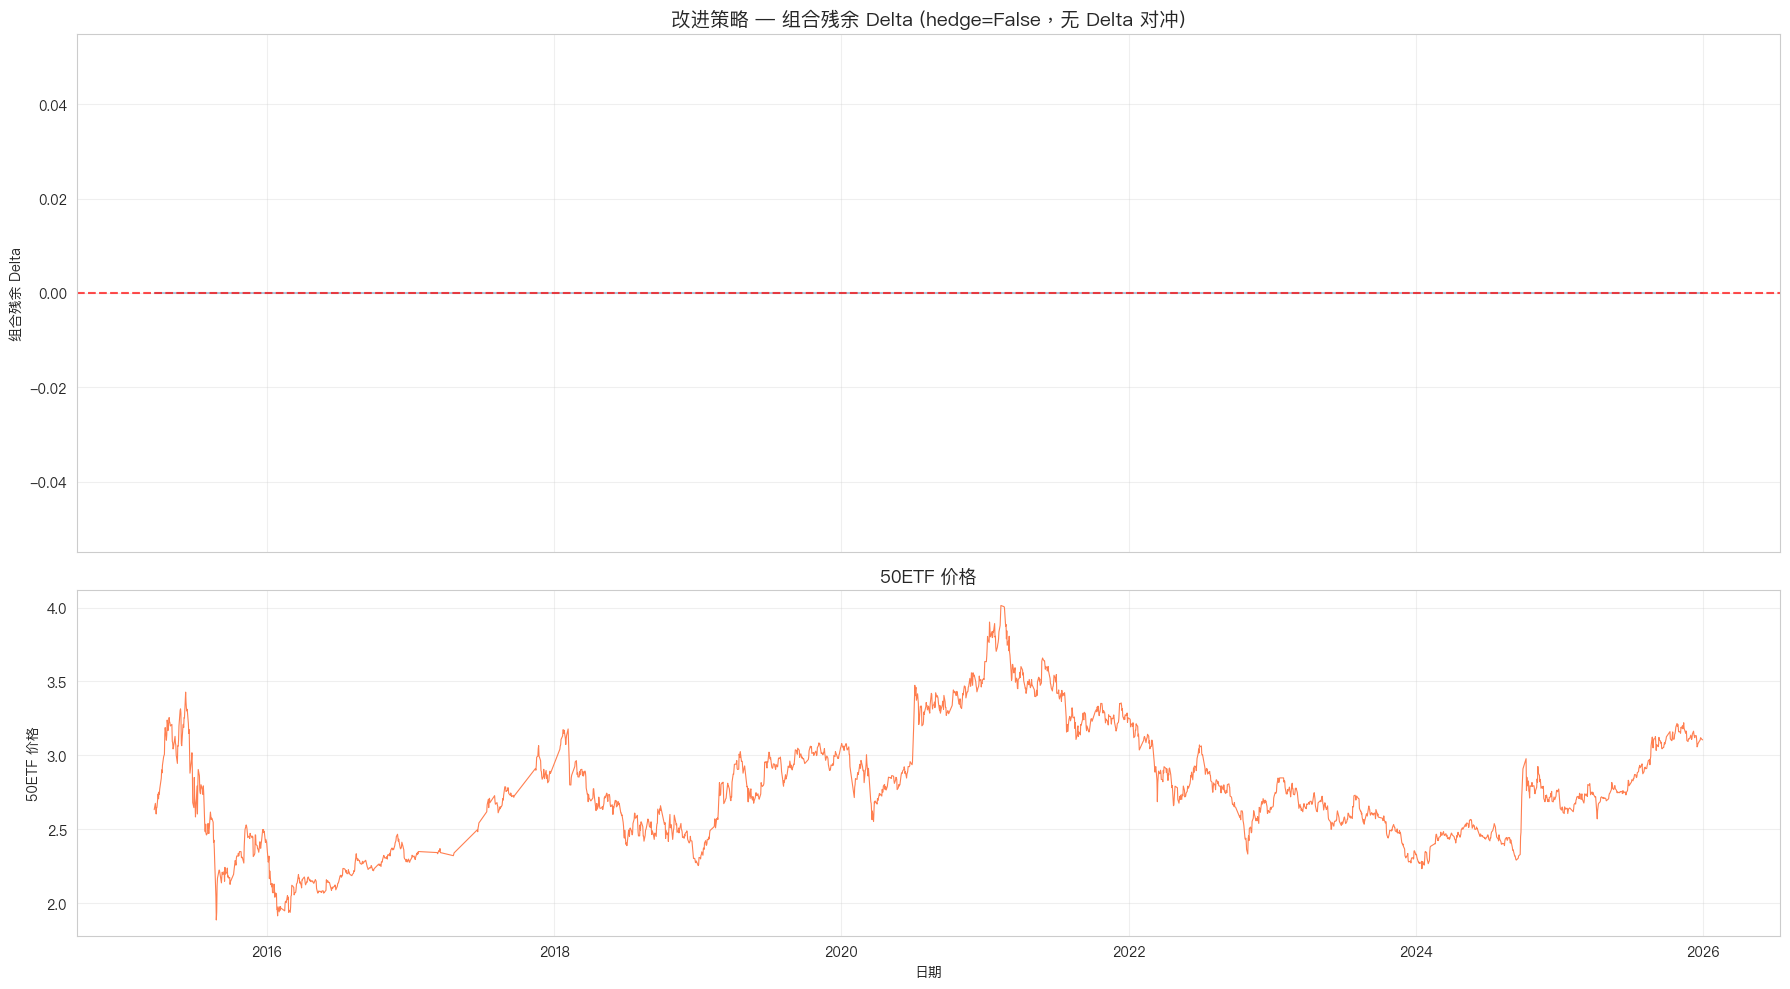

Delta 统计:
  平均残余 Delta: 0
  Delta 标准差: 0


In [7]:
# 2.1 残余 Delta 时间序列
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True,
                         gridspec_kw={'height_ratios': [1.5, 1]})

axes[0].plot(greeks_daily.index, greeks_daily['portfolio_delta'], linewidth=0.6, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
axes[0].set_ylabel('组合残余 Delta')
axes[0].set_title('改进策略 — 组合残余 Delta (hedge=False，无 Delta 对冲)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(greeks_daily.index, greeks_daily['etf_price'], linewidth=0.8, color='coral')
axes[1].set_ylabel('50ETF 价格')
axes[1].set_xlabel('日期')
axes[1].set_title('50ETF 价格', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + '06_delta_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Delta 统计:')
print(f'  平均残余 Delta: {greeks_daily["portfolio_delta"].mean():,.0f}')
print(f'  Delta 标准差: {greeks_daily["portfolio_delta"].std():,.0f}')

## 3. Gamma 风险拆解

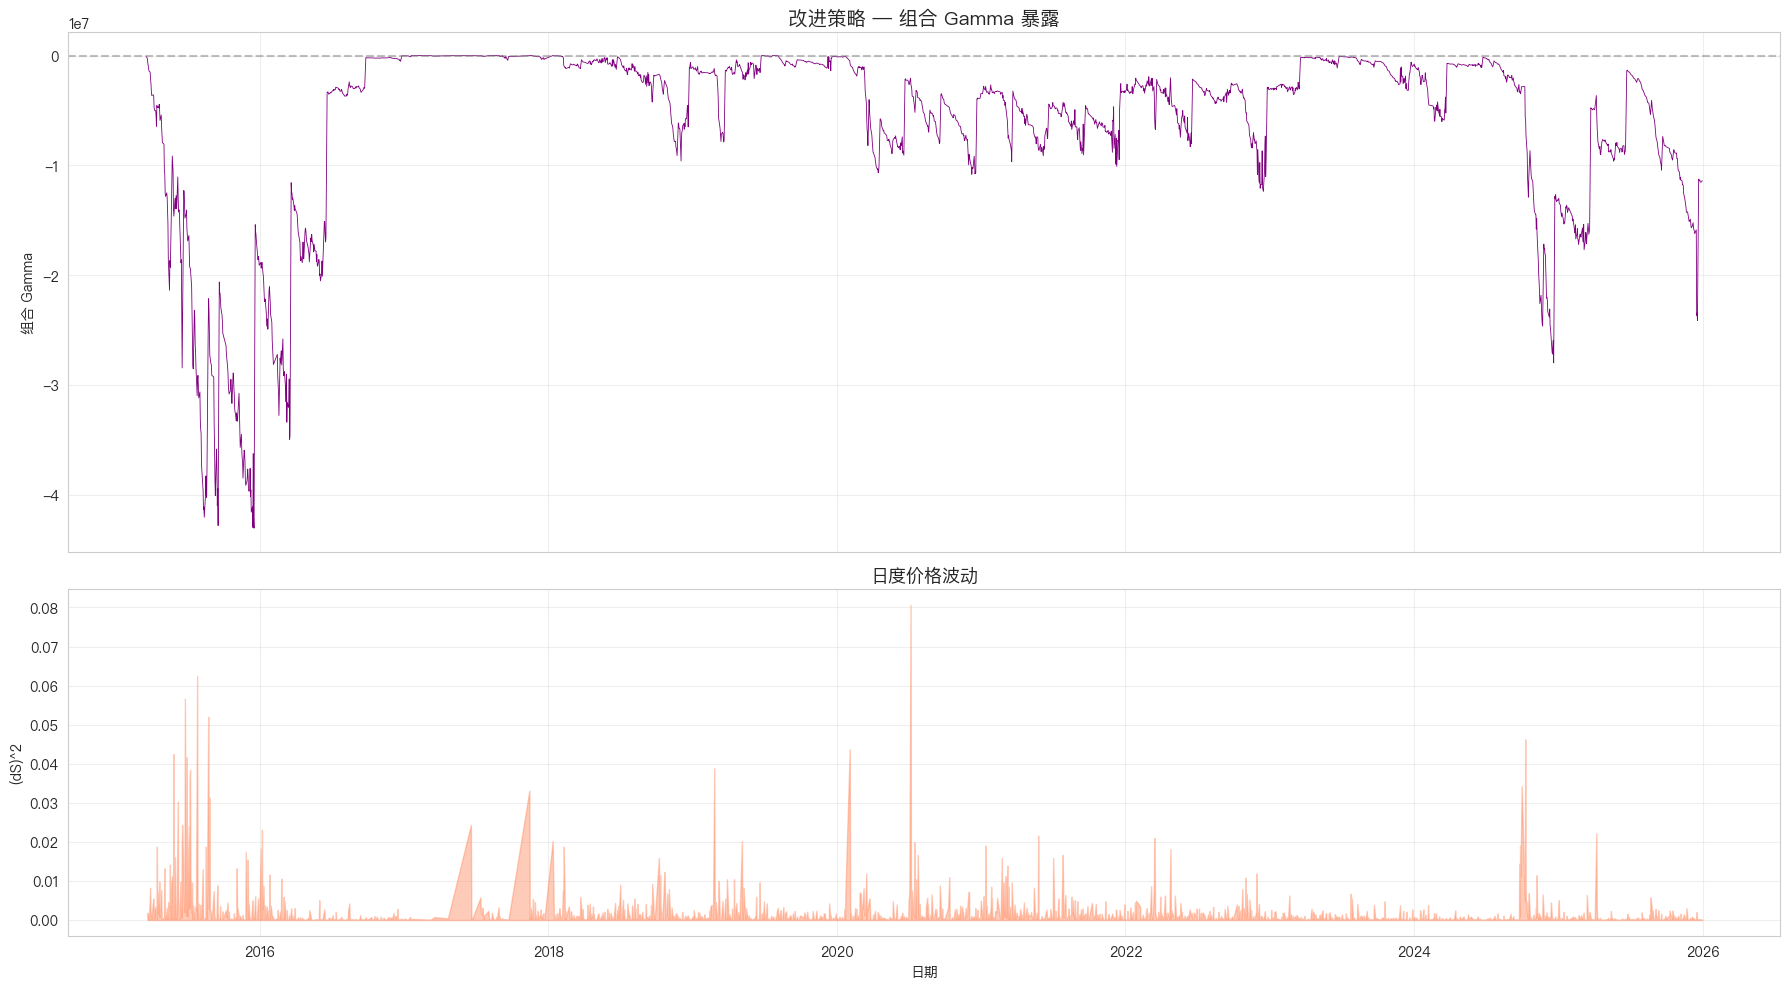

Gamma 统计:
  平均 Gamma: -6,328,465
  累计 Gamma P&L: -16,595,921 元


In [8]:
# 3.1 组合 Gamma 时间序列
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True,
                         gridspec_kw={'height_ratios': [1.5, 1]})

axes[0].plot(greeks_daily.index, greeks_daily['portfolio_gamma'], linewidth=0.6, color='purple')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_ylabel('组合 Gamma')
axes[0].set_title('改进策略 — 组合 Gamma 暴露', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(greeks_daily.index, greeks_daily['dS']**2, 0, alpha=0.4, color='coral')
axes[1].set_ylabel('(dS)^2')
axes[1].set_xlabel('日期')
axes[1].set_title('日度价格波动', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + '06_gamma_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Gamma 统计:')
print(f'  平均 Gamma: {greeks_daily["portfolio_gamma"].mean():,.0f}')
print(f'  累计 Gamma P&L: {greeks_daily["gamma_pnl"].sum():,.0f} 元')

## 4. 组合 P&L 归因

将总 P&L 分解为：
- **Theta 收益**：时间价值衰减
- **Gamma 损失**：价格波动的非线性损失
- **Vega 损益**：隐含波动率变化
- **Delta 损益**：期权方向性暴露（对冲 P&L 计入残差）
- **残差**：Delta 对冲 P&L、交易成本、模型误差等

In [9]:
# 4.1 P&L 归因汇总表
attribution = {
    'Theta (时间衰减)': greeks_daily['theta_pnl'].sum(),
    'Gamma (价格波动)': greeks_daily['gamma_pnl'].sum(),
    'Vega (波动率变化)': greeks_daily['vega_pnl'].sum(),
    'Delta (期权方向性)': greeks_daily['delta_pnl'].sum(),
    '残差 (对冲+成本等)': greeks_daily['residual_pnl'].sum(),
}
attr_df = pd.Series(attribution)
total_actual = greeks_daily['daily_pnl'].sum()

print('=== 改进策略 P&L 归因 ===')
print(f'{"成分":<20s} {"金额 (元)":>15s} {"占比":>10s}')
print('-' * 48)
for name, val in attribution.items():
    pct = val / total_actual * 100 if total_actual != 0 else 0
    print(f'{name:<20s} {val:>15,.0f} {pct:>9.1f}%')
print('-' * 48)
print(f'{"总 P&L":<20s} {total_actual:>15,.0f} {100:>9.1f}%')
print(f'{"归因合计":<20s} {attr_df.sum():>15,.0f} {attr_df.sum()/total_actual*100:>9.1f}%')


=== 改进策略 P&L 归因 ===
成分                            金额 (元)         占比
------------------------------------------------
Theta (时间衰减)              28,802,528     191.7%
Gamma (价格波动)             -16,595,921    -110.4%
Vega (波动率变化)               1,961,771      13.1%
Delta (期权方向性)             20,033,290     133.3%
残差 (对冲+成本等)              -19,174,216    -127.6%
------------------------------------------------
总 P&L                     15,027,380     100.0%
归因合计                      15,027,452     100.0%


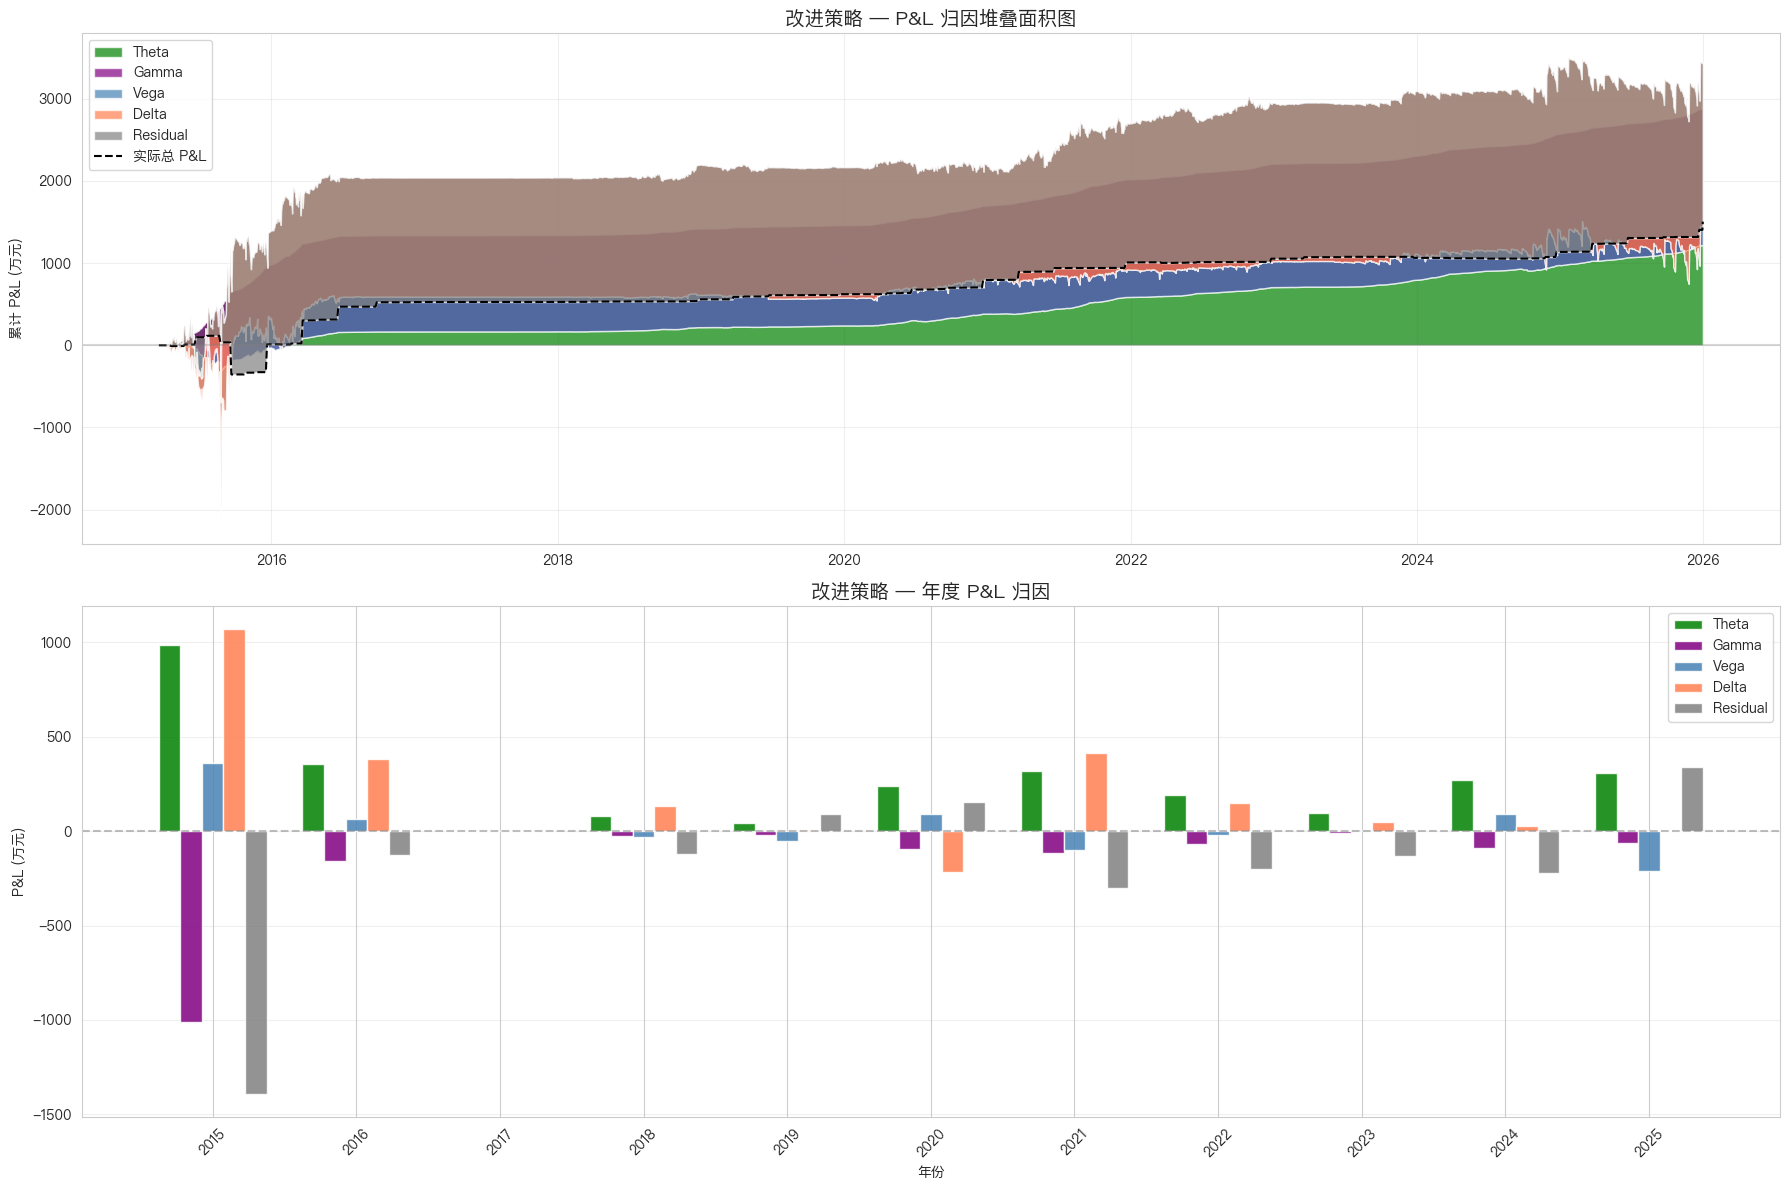

In [10]:
# 4.2 P&L 归因堆叠面积图
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

components = ['theta_pnl', 'gamma_pnl', 'vega_pnl', 'delta_pnl', 'residual_pnl']
labels = ['Theta', 'Gamma', 'Vega', 'Delta', 'Residual']
colors = ['green', 'purple', 'steelblue', 'coral', 'gray']

cum_data = pd.DataFrame(index=greeks_daily.index)
for comp, label in zip(components, labels):
    cum_data[label] = greeks_daily[comp].fillna(0).cumsum() / 10000

axes[0].stackplot(cum_data.index,
                  [cum_data[label].values for label in labels],
                  labels=labels, colors=colors, alpha=0.7)
axes[0].plot(greeks_daily.index, equity.reindex(greeks_daily.index, fill_value=0) / 10000,
             linewidth=1.5, color='black', linestyle='--', label='实际总 P&L')
axes[0].set_ylabel('累计 P&L (万元)')
axes[0].set_title('改进策略 — P&L 归因堆叠面积图', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='gray', linestyle='-', alpha=0.3)

# Annual
annual_attr = greeks_daily[components].copy()
annual_attr.columns = labels
annual_attr['year'] = greeks_daily.index.year
annual_sum = annual_attr.groupby('year').sum() / 10000

x = np.arange(len(annual_sum.index))
width = 0.15
for i, (label, color) in enumerate(zip(labels, colors)):
    axes[1].bar(x + (i - 2) * width, annual_sum[label], width,
                color=color, alpha=0.85, label=label)
axes[1].set_xticks(x)
axes[1].set_xticklabels(annual_sum.index, rotation=45)
axes[1].set_xlabel('年份')
axes[1].set_ylabel('P&L (万元)')
axes[1].set_title('改进策略 — 年度 P&L 归因', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(SAVE_DIR + '06_pnl_attribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. 收益分布与回撤结构

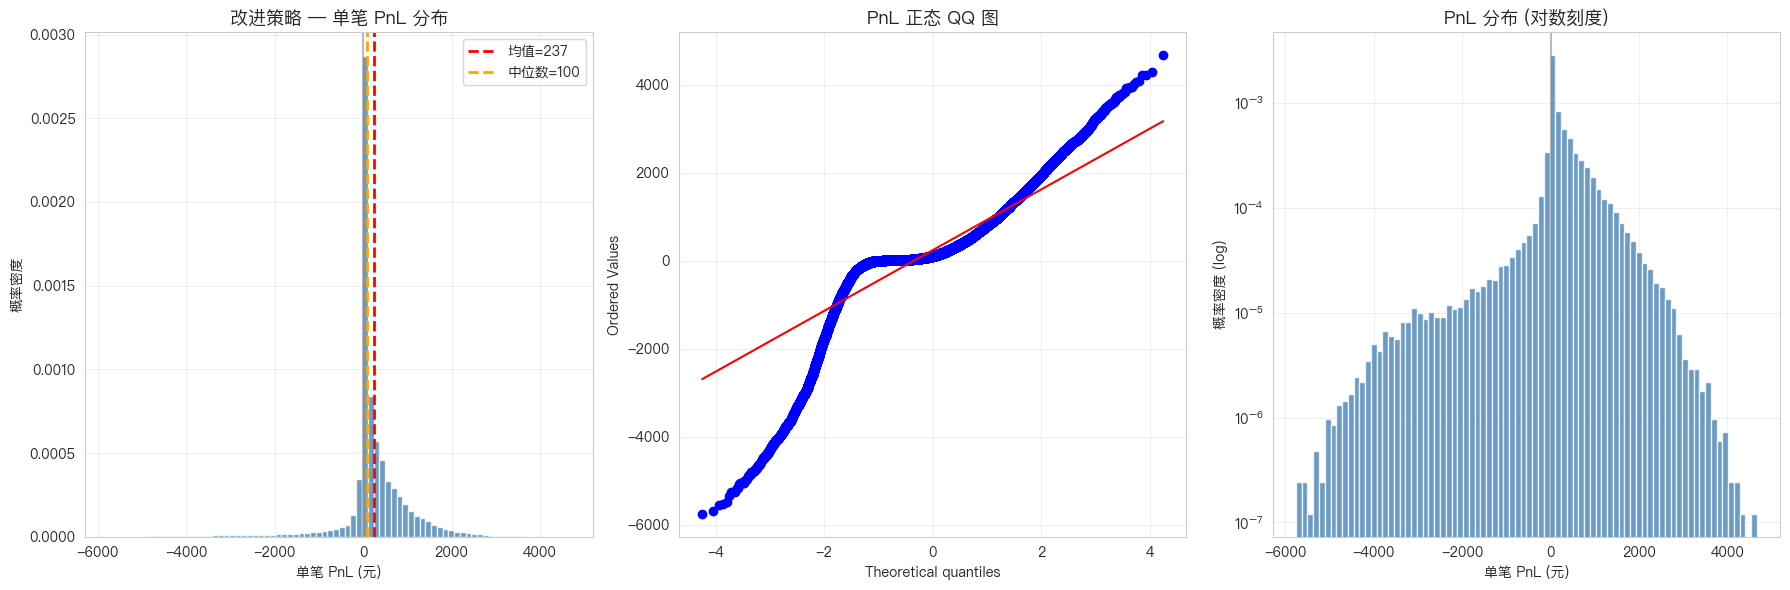

=== 单笔 PnL 分布统计 ===
  均值: 237
  中位数: 100
  标准差: 774
  偏度: -1.102
  峰度: 8.649
  VaR (5%): -690
  VaR (1%): -2939
  ES (5%): -1942


In [11]:
# 5.1 单笔 PnL 分布
pnls = np.array([t.pnl for t in all_trades])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].hist(pnls, bins=80, color='steelblue', alpha=0.8, edgecolor='white', density=True)
axes[0].axvline(x=np.mean(pnls), color='red', linestyle='--', linewidth=2, label=f'均值={np.mean(pnls):.0f}')
axes[0].axvline(x=np.median(pnls), color='orange', linestyle='--', linewidth=2, label=f'中位数={np.median(pnls):.0f}')
axes[0].axvline(x=0, color='gray', linestyle='-', alpha=0.5)
axes[0].set_xlabel('单笔 PnL (元)')
axes[0].set_ylabel('概率密度')
axes[0].set_title('改进策略 — 单笔 PnL 分布', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

stats.probplot(pnls, dist='norm', plot=axes[1])
axes[1].set_title('PnL 正态 QQ 图', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].hist(pnls, bins=80, color='steelblue', alpha=0.8, edgecolor='white', density=True)
axes[2].set_yscale('log')
axes[2].axvline(x=0, color='gray', linestyle='-', alpha=0.5)
axes[2].set_xlabel('单笔 PnL (元)')
axes[2].set_ylabel('概率密度 (log)')
axes[2].set_title('PnL 分布 (对数刻度)', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + '06_pnl_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== 单笔 PnL 分布统计 ===')
print(f'  均值: {np.mean(pnls):.0f}')
print(f'  中位数: {np.median(pnls):.0f}')
print(f'  标准差: {np.std(pnls):.0f}')
print(f'  偏度: {pd.Series(pnls).skew():.3f}')
print(f'  峰度: {pd.Series(pnls).kurtosis():.3f}')
print(f'  VaR (5%): {np.percentile(pnls, 5):.0f}')
print(f'  VaR (1%): {np.percentile(pnls, 1):.0f}')
worst = pnls[pnls <= np.percentile(pnls, 5)]
print(f'  ES (5%): {worst.mean():.0f}')

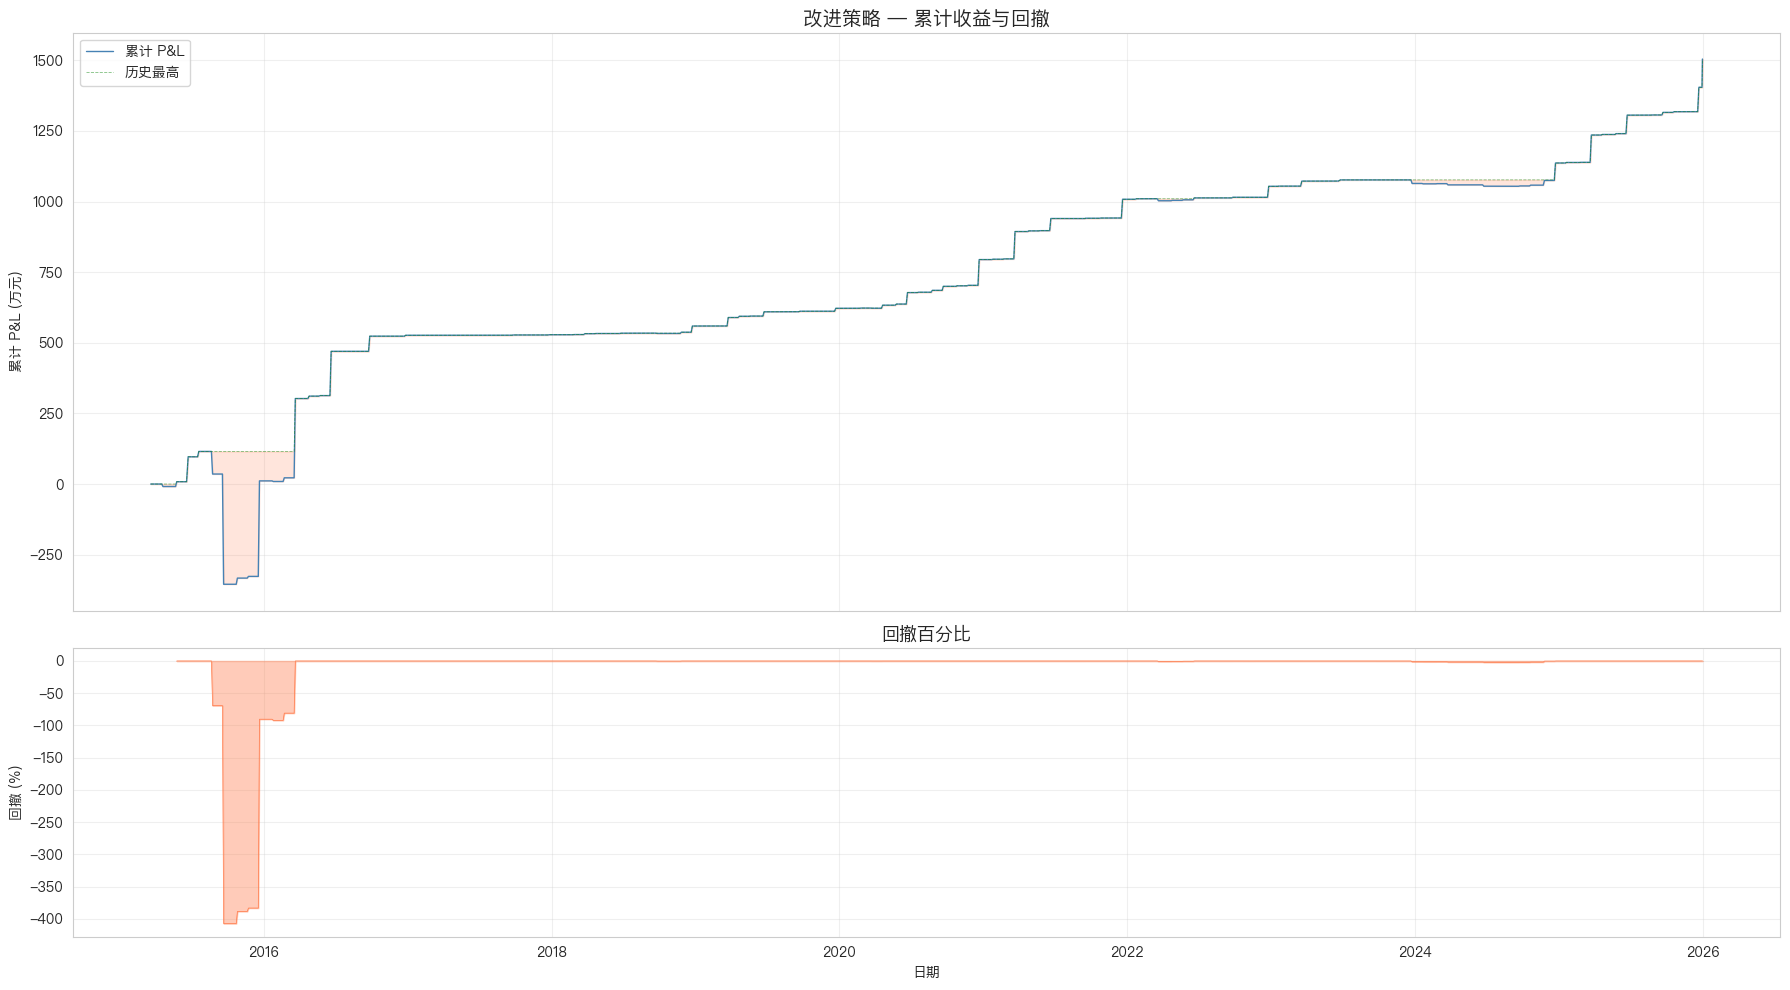

=== 回撤统计 ===
  最大回撤: -4,702,103 元 (-inf%)
  最大回撤日期: 2015-04-20
  回撤 > 5% 天数: 161 / 2625


In [12]:
# 5.2 回撤分析
if not equity.empty:
    cummax = equity.cummax()
    drawdown = equity - cummax
    dd_pct = drawdown / cummax * 100

    fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})

    axes[0].plot(equity.index, equity.values / 10000, linewidth=1, color='steelblue', label='累计 P&L')
    axes[0].plot(equity.index, cummax.values / 10000, linewidth=0.6, color='green',
                linestyle='--', alpha=0.5, label='历史最高')
    axes[0].fill_between(equity.index, equity.values / 10000, cummax.values / 10000,
                        alpha=0.2, color='coral')
    axes[0].set_ylabel('累计 P&L (万元)')
    axes[0].set_title('改进策略 — 累计收益与回撤', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].fill_between(dd_pct.index, dd_pct.values, 0, alpha=0.4, color='coral')
    axes[1].plot(dd_pct.index, dd_pct.values, linewidth=0.5, color='coral')
    axes[1].set_ylabel('回撤 (%)')
    axes[1].set_xlabel('日期')
    axes[1].set_title('回撤百分比', fontsize=13)
    axes[1].grid(True, alpha=0.3)

    max_dd_idx = dd_pct.idxmin()
    axes[1].annotate(f'最大回撤: {dd_pct.min():.1f}%\n({max_dd_idx.date()})',
                    xy=(max_dd_idx, dd_pct.min()), xytext=(max_dd_idx, dd_pct.min() - 2),
                    arrowprops=dict(arrowstyle='->', color='red'),
                    fontsize=10, color='red', ha='center')

    plt.tight_layout()
    plt.savefig(SAVE_DIR + '06_drawdown.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('=== 回撤统计 ===')
    print(f'  最大回撤: {drawdown.min():,.0f} 元 ({dd_pct.min():.1f}%)')
    print(f'  最大回撤日期: {max_dd_idx.date()}')
    print(f'  回撤 > 5% 天数: {(dd_pct < -5).sum()} / {len(dd_pct)}')

## 6. 基准 vs 改进策略对比

In [13]:
# 6.1 对比基准与改进策略的关键指标
# 基准策略数据来自 04 notebook 的运行结果
# 这里用改进策略的数据做汇总

print('=== 改进策略风险指标汇总 ===')
print()
print(f'总交易笔数: {len(all_trades)}')
print(f'  Call: {len(trades_c)}, Put: {len(trades_p)}')
wins = [t for t in all_trades if t.pnl > 0]
losses = [t for t in all_trades if t.pnl <= 0]
print(f'胜率: {len(wins)/len(all_trades)*100:.1f}%')
print(f'总 PnL: {total_pnl:,.0f} 元')
print(f'平均 PnL: {np.mean(pnls):.0f} 元')
print(f'偏度: {pd.Series(pnls).skew():.3f}')
print(f'峰度: {pd.Series(pnls).kurtosis():.3f}')
print(f'VaR (5%): {np.percentile(pnls, 5):.0f} 元')
print()
print('Greeks 暴露:')
print(f'  平均 Vega: {greeks_daily["portfolio_vega"].mean():,.0f}')
print(f'  平均 Gamma: {greeks_daily["portfolio_gamma"].mean():,.0f}')
print(f'  平均 Delta: {greeks_daily["portfolio_delta"].mean():,.0f}')
print(f'  平均 Theta: {greeks_daily["portfolio_theta"].mean():,.0f}')

=== 改进策略风险指标汇总 ===

总交易笔数: 63535
  Call: 16214, Put: 47321
胜率: 83.8%
总 PnL: 15,046,317 元
平均 PnL: 237 元
偏度: -1.102
峰度: 8.649
VaR (5%): -690 元

Greeks 暴露:
  平均 Vega: -53,785
  平均 Gamma: -6,328,465
  平均 Delta: 0
  平均 Theta: 11,633


In [14]:
# 6.2 基准 vs 改进 对比表
print('=== 基准 vs 改进策略对比 ===')
print()
print(f'{"指标":<20s} {"基准策略":>15s} {"改进策略":>15s}')
print('-' * 52)
print(f'{"策略类型":<20s} {"Call only":>15s} {"Call+Put":>15s}')
print(f'{"阈值":<20s} {"固定":>15s} {"滚动":>15s}')
print(f'{"对冲":<20s} {"每日 Delta":>15s} {"停止交易":>15s}')
print(f'{"交易笔数":<20s} {24042:>15,d} {len(all_trades):>15,d}')
print(f'{"胜率":<20s} {"83.5%":>15s} {len(wins)/len(all_trades)*100:>14.1f}%')
print(f'{"总 PnL":<20s} {"1,737,284":>15s} {total_pnl:>14,.0f}')
print()
print('风险特征差异:')
print('  - 改进策略不进行 Delta 对冲，Delta 暴露更大')
print('  - 改进策略通过停止交易(min_t=7)降低 Gamma 风险')
print('  - Call+Put 组合分散了 Vega 暴露')
print('  - 滚动阈值更好地适应了市场变化')

=== 基准 vs 改进策略对比 ===

指标                              基准策略            改进策略
----------------------------------------------------
策略类型                       Call only        Call+Put
阈值                                固定              滚动
对冲                          每日 Delta            停止交易
交易笔数                          24,042          63,535
胜率                             83.5%           83.8%
总 PnL                      1,737,284     15,046,317

风险特征差异:
  - 改进策略不进行 Delta 对冲，Delta 暴露更大
  - 改进策略通过停止交易(min_t=7)降低 Gamma 风险
  - Call+Put 组合分散了 Vega 暴露
  - 滚动阈值更好地适应了市场变化
